In [1]:
import pandas as pd
import numpy as np

In [12]:
# Read `items.csv` making `item_name` as index.
items=pd.read_csv("items.csv", index_col="item_name")
# Show no of nan values
items.isna().sum() #counts True values in each column (NaNs).
#.count counts the non nan values
# Item price is given in $, so convert it to rupees without currency symbol.
usd_to_pkr = 283
items['item_price'] = items['item_price'].replace('[\$,]', '', regex=True).astype(float)
items['price_inr'] = items['item_price'] * usd_to_pkr
print(items.head())

                                       item_price  price_inr
item_name                                                   
Chips and Fresh Tomato Salsa                 2.39     676.37
Izze                                         3.39     959.37
Nantucket Nectar                             3.39     959.37
Chips and Tomatillo-Green Chili Salsa        2.39     676.37
Chicken Bowl                                16.98    4805.34


<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
C:\Users\PMLS\AppData\Local\Temp\ipykernel_17772\1531583047.py:8: SyntaxWarning: invalid escape sequence '\$'
  items['item_price'] = items['item_price'].replace('[\$,]', '', regex=True).astype(float)


7.463031496062992
30th percentile: 4.45
6th percentile: 1.25


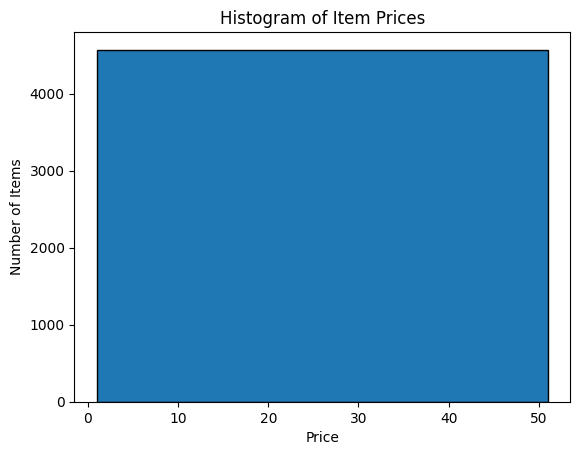

Number of items with price between 1000 and 2000: 0


In [19]:
import matplotlib.pyplot as plt
# i. Find mean price
mean=items["item_price"].mean()
print(mean)
# ii. Find 30th and 6th percentile value
prices = items['item_price'].dropna()
p30 = np.percentile(prices, 30)
p6 = np.percentile(prices, 6)
print("30th percentile:", p30)
print("6th percentile:", p6)
# iii. Plot Histogram on price with bin size 50
plt.hist(items['item_price'], bins=range(int(items['item_price'].min()), int(items['item_price'].max()) + 50, 50), edgecolor='black')
plt.title("Histogram of Item Prices")
plt.xlabel("Price")
plt.ylabel("Number of Items")
plt.show()
# iv. No of items price lies between [1000 to 2000]
count = items['item_price'].between(1000, 2000).sum()
print("Number of items with price between 1000 and 2000:", count)